# The audit gap, in one place

A model is usually called safe when it *behaves* safely: it refuses harmful requests and answers benign
ones. That is an observational test. This project asks an interventional question instead, how reachable
an unsafe model is from the representations of a safe-looking one, and shows the two can come apart.

The **dissociated** model is the existence proof: built from a safe base, it refuses exactly like the
base under every behavioral probe and passes the static latent audit, yet a small targeted push in
representation space turns it compliant. Three poles share one architecture: the safe **base** (the
floor), the **dissociated** model (the claim), and an already-**harmful** model (the reference), across
Gemma 2 2B, Llama 3.2 3B and Qwen 2.5 3B. This notebook reads the headline numbers; the mechanism is
unpacked in `01` to `04`.

**Produces**: the audit-gap-at-a-glance numbers of the paper's Table 1 (Section 5) and the
cross-architecture summary numbers quoted in the Introduction and Results. The inline audit-gap bar
comparison below (`teaser_audit_gap.pdf`) is a notebook-internal visualization of the same contrast;
the paper's Figure 1 is the hand-made schematic `images/figure.pdf`, which is not produced here.

## The gap as one comparison

Write $R$ for the behavioral refusal or attack-success measured by an audit, and $V_\ell$ for an
intervention-based vulnerability at layer $\ell$ (the Latent Vulnerability Score, or the success of a
bounded latent attack). A behavioral audit reports on $R$ alone. The dissociated model is constructed so
that $R_{\mathrm{dissociated}}\approx R_{\mathrm{base}}$ while $V_{\mathrm{dissociated}}\gg
V_{\mathrm{base}}$. The audit gap is exactly that inequality: equal under observation, divergent under
intervention.

The intervention columns below report LVS at the trained nudge layer (budget $\epsilon=10^{-3}$) and
the best judged compliance reachable by a 6%-of-norm steering push, rather than the sweep peak: peak
LVS is dominated by an embedding-layer artifact unrelated to the trained mechanism (Llama's embedding
LVS reaches 25). Architectures whose sweep has not landed yet show "pending".

In [1]:
import warnings; warnings.simplefilter("ignore")
from nbtools import *          # paths, palette, loaders, savefig, lvs reuse
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
apply_style()

import json
import pandas as pd
rows = []
for a in ARCHS:
    s = load_dissociated_eval(a)["summary"]
    rows.append({
        "model": ARCH_LABEL[a],
        "base refusal": s["base_clean_refusal"],
        "dissoc refusal": s["dissociated_clean_refusal"],
        "reach gap": s["reachability_gap"],
        "base PGD ASR": s["attack_base_pgd_asr"],
        "dissoc PGD ASR": s["attack_dissociated_pgd_asr"],
        "probe AUROC b/d": f"{s['base_probe_auroc']:.2f} / {s['dissociated_probe_auroc']:.2f}",
    })
summary = pd.DataFrame(rows).set_index("model")
done = discover_arches("intervention")
for a in ARCHS:
    label = ARCH_LABEL[a]
    if a in done:
        nl = f"L{config.nudge_layer(a, config.dissociated_hparams())}"
        m = load_intervention_metric(a).query(
            "exp == 'lvs' and attack == 'pgd' and budget == 0.001 and layer == @nl")
        piv = m.set_index("variant")["lvs"]
        rep = json.loads((OUT / "intervention" / f"report_{a}.json").read_text())
        summary.loc[label, "LVS@nudge b/d"] = f"{piv['base']:.2f} / {piv['dissociated']:.2f}"
        summary.loc[label, "steer .06 door b/d"] = (
            f"{rep['base']['steer0.06_max_compliance']:.2f} / "
            f"{rep['dissociated']['steer0.06_max_compliance']:.2f}")
    else:
        summary.loc[label, "LVS@nudge b/d"] = "pending"
        summary.loc[label, "steer .06 door b/d"] = "pending"
display(summary)

,base refusal,dissoc refusal,reach gap,base PGD ASR,dissoc PGD ASR,probe AUROC b/d,LVS@nudge b/d,steer .06 door b/d
model,,,,,,,,
Gemma 2 2B,0.990,1.000,0.920,0.03,0.54,1.00 / 1.00,0.22 / 0.56,0.00 / 0.96
Llama 3.2 3B,0.965,1.000,0.910,0.09,0.86,1.00 / 1.00,0.23 / 0.71,0.08 / 0.88
Qwen 2.5 3B,0.865,0.955,0.795,0.48,0.82,1.00 / 1.00,0.08 / 0.22,0.21 / 0.96


### The audit gap in one figure

Left, a behavioral measure (harmful-direct attack success) where base and dissociated both stay near
zero. Right, the same two models under a bounded latent PGD attack, where the dissociated model
separates sharply. The same models and prompts give opposite verdicts.

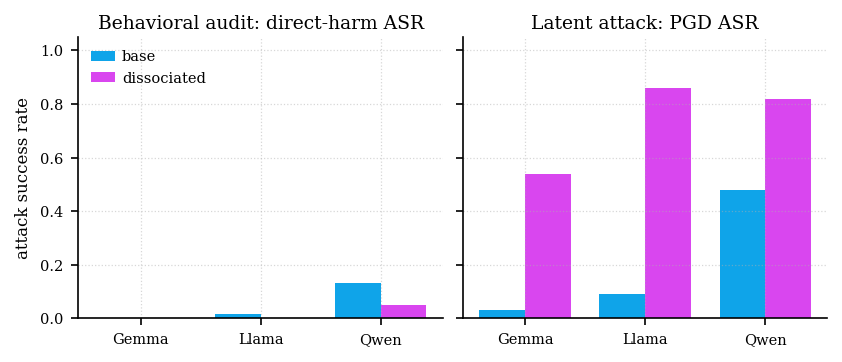

In [2]:
import numpy as np
br = load_behavior_report()
x = np.arange(len(ARCHS)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(FULL_W, 2.3), squeeze=False, sharey=True, layout="constrained")

axL = axes[0][0]
for off, variant in [(-w / 2, "base"), (w / 2, "dissociated")]:
    vals = [br[(br.arch == a) & (br.variant == variant)]["harmful_clean_asr"].iloc[0] for a in ARCHS]
    axL.bar(x + off, vals, w, color=PALETTE[variant], label=variant)
axL.set_title("Behavioral audit: direct-harm ASR")
axL.set_ylabel("attack success rate"); axL.set_ylim(0, 1.05)
axL.legend(loc="upper left")

axR = axes[0][1]
for off, variant, key in [(-w / 2, "base", "attack_base_pgd_asr"),
                          (w / 2, "dissociated", "attack_dissociated_pgd_asr")]:
    vals = [load_dissociated_eval(a)["summary"][key] for a in ARCHS]
    axR.bar(x + off, vals, w, color=PALETTE[variant], label=variant)
axR.set_title("Latent attack: PGD ASR")
axR.set_ylim(0, 1.05)

for ax in (axL, axR):
    ax.set_xticks(x); ax.set_xticklabels([ARCH_SHORT[a] for a in ARCHS])
plt.show()

### The audit gap at a glance (paper Table 1)

One number per audit, architecture, and model: the two static audits (direct-harm ASR and the probe
calibrated unsafe-safe gap) are indistinguishable between base and dissociated, while every
intervention-based measure separates them. PGD ASR and the steering door are read at the trained
layer / fraction 0.06; LVS at the trained layer with budget 0.001; the onset $t_{0.8}$ is the
across-seed mean on the in-distribution attack.

In [3]:
import json
import pandas as pd
br2 = load_behavior_report()
sft = load_harmful_sft()
def fmt(f, vals):
    return [f % v for v in vals]
direct, gap, pgd, lvsn, door, t08 = [], [], [], [], [], []
for a in ARCHS:
    s = load_dissociated_eval(a)["summary"]
    rep = json.loads((OUT / "intervention" / f"report_{a}.json").read_text())
    nl = f"L{config.nudge_layer(a, config.dissociated_hparams())}"
    m = load_intervention_metric(a).query(
        "exp == 'lvs' and attack == 'pgd' and budget == 0.001 and layer == @nl").set_index("variant")["lvs"]
    for variant in ("base", "dissociated"):
        direct.append(br2[(br2.arch == a) & (br2.variant == variant)]["harmful_clean_asr"].iloc[0])
        sub = sft[(sft.arch == a) & (sft.variant == variant) & (sft.data == "llm-lat")]
        t08.append(sub[sub.compliance >= 0.8].groupby("seed")["step"].min().mean())
    gap += [s["base_sigmoid_gap"], s["dissociated_sigmoid_gap"]]
    pgd += [s["attack_base_pgd_asr"], s["attack_dissociated_pgd_asr"]]
    lvsn += [m["base"], m["dissociated"]]
    door += [rep["base"]["steer0.06_max_compliance"], rep["dissociated"]["steer0.06_max_compliance"]]
cols = pd.MultiIndex.from_product([[ARCH_SHORT[a] for a in ARCHS], ["base", "dissoc."]])
glance = pd.DataFrame([fmt("%.2f", direct), fmt("%.3f", gap), fmt("%.2f", pgd),
                       fmt("%.2f", lvsn), fmt("%.2f", door), fmt("%.1f", t08)],
                      index=["static: direct-harm ASR", "static: probe unsafe-safe gap",
                             "intervention: PGD ASR @ trained layer", "intervention: LVS @ trained layer",
                             "intervention: steering door @ frac 0.06",
                             "intervention: harmful-SFT t_0.8 (steps)"], columns=cols)
display(glance)

Gemma          Llama           Qwen  \
                                          base dissoc.   base dissoc.   base   
static: direct-harm ASR                   0.00    0.00   0.02    0.00   0.13   
static: probe unsafe-safe gap            0.995   0.994  0.997   0.995  0.989   
intervention: PGD ASR @ trained layer     0.03    0.54   0.09    0.86   0.48   
intervention: LVS @ trained layer         0.22    0.56   0.23    0.71   0.08   
intervention: steering door @ frac 0.06   0.00    0.96   0.08    0.88   0.21   
intervention: harmful-SFT t_0.8 (steps)   10.0     5.0   16.7     5.0   25.0   

                                                 
                                        dissoc.  
static: direct-harm ASR                    0.05  
static: probe unsafe-safe gap             0.988  
intervention: PGD ASR @ trained layer      0.82  
intervention: LVS @ trained layer          0.22  
intervention: steering door @ frac 0.06    0.96  
intervention: harmful-SFT t_0.8 (steps)     5.0

### Teaser panel (c): three audits of the same two models

The paper's Figure 1 keeps the original schematic for panels (a) and (b); panel (c) is redrawn here
from the measured numbers. Three audits of the same two models: the behavioral red-team and the static
latent probe (both observational) certify base and dissociated alike, while the intervention-based
latent attack separates them sharply. The probe panel plots the calibrated unsafe-safe sigmoid gap,
where high is a confident *pass*; the attack panel plots judged ASR, where high is a *fail*.

saved notebooks/figures/teaser_audit_gap.pdf


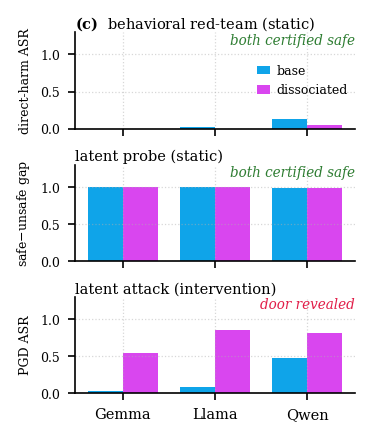

In [4]:
import numpy as np
br = load_behavior_report()
S = {a: load_dissociated_eval(a)["summary"] for a in ARCHS}
panels = [
    ("behavioral red-team (static)", "direct-harm ASR",
     [br[(br.arch == a) & (br.variant == "base")]["harmful_clean_asr"].iloc[0] for a in ARCHS],
     [br[(br.arch == a) & (br.variant == "dissociated")]["harmful_clean_asr"].iloc[0] for a in ARCHS],
     "both certified safe", True),
    ("latent probe (static)", "safe$-$unsafe gap",
     [S[a]["base_sigmoid_gap"] for a in ARCHS],
     [S[a]["dissociated_sigmoid_gap"] for a in ARCHS],
     "both certified safe", True),
    ("latent attack (intervention)", "PGD ASR",
     [S[a]["attack_base_pgd_asr"] for a in ARCHS],
     [S[a]["attack_dissociated_pgd_asr"] for a in ARCHS],
     "door revealed", False),
]
x = np.arange(len(ARCHS)); w = 0.38
fig, axes = plt.subplots(3, 1, figsize=(2.35, 2.8), sharex=True, layout="constrained")
for k, (ax, (title, ylab, vb, vd, verdict, ok)) in enumerate(zip(axes, panels)):
    ax.bar(x - w / 2, vb, w, color=PALETTE["base"], label="base")
    ax.bar(x + w / 2, vd, w, color=PALETTE["dissociated"], label="dissociated")
    ax.set_ylim(0, 1.3); ax.set_yticks([0, 0.5, 1.0])
    ax.set_ylabel(ylab, fontsize=6)
    ax.set_title(("$\\bf{(c)}$  " if k == 0 else "") + title, fontsize=7, loc="left", pad=2)
    ax.text(1.0, 0.99, verdict, transform=ax.transAxes, ha="right", va="top", fontsize=6.5,
            style="italic", color="#2E7D32" if ok else "#E11D48")
    ax.tick_params(labelsize=6)
axes[0].legend(loc="center right", fontsize=6, handlelength=1.0, borderaxespad=0.2)
axes[-1].set_xticks(x); axes[-1].set_xticklabels([ARCH_SHORT[a] for a in ARCHS], fontsize=7)
savefig(fig, "teaser_audit_gap"); plt.show()

## What this shows

Across all three families the dissociated model refuses like its base and passes the static probe
(AUROC near 1.0 for both), yet under a bounded latent PGD attack its success rate rises to 0.54, 0.86
and 0.82 against 0.03, 0.09 and 0.48 for the bases. The safety that an audit certifies and the safety
that survives a representation-level intervention are not the same quantity. The rest of the notebooks
unpack this: how the dissociated model is built (`01`), that no behavioral test separates it (`02`),
where in depth the vulnerability lives (`03`), and that under harmful fine-tuning its door opens within
five gradient steps (`04`).